## Initial baseline model

**Imports.** Standard libraries plus NumPy/Pandas, sklearn, visualization, and project modules for preprocessing, PyTorch OCR helpers, zonal/basic OCR, and dashboards.


In [39]:
# Imports
import random
import os
import json
import re
from pathlib import Path
import tqdm
import cv2
from scipy import ndimage


import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

from scripts.preprocess import *
from scripts.pt_model import *
from scripts.layoutlmv3_model import *
from scripts.basic_model import *

from scripts.visualize_util import create_analysis_dashboard, visualize_sample_results

**Ground truth.** Load the cleaned invoice labels CSV (`cleaned_invoices.csv`) used for all evaluations.


In [40]:
ground_truth_df = pd.read_csv("../finalproject_data/cleaned_invoices.csv")
print(ground_truth_df.columns)

Index(['File Name', 'OCRed Text', 'batch_csv', 'client_name', 'seller_name',
       'invoice_number', 'invoice_date', 'due_date', 'tax', 'total_amount',
       'net_worth'],
      dtype='str')


**Zonal OCR setup.** Define normalized field zones, build `InvoiceZonalOCRPipeline`, preview zones on a sample image, and run a single-invoice smoke test.


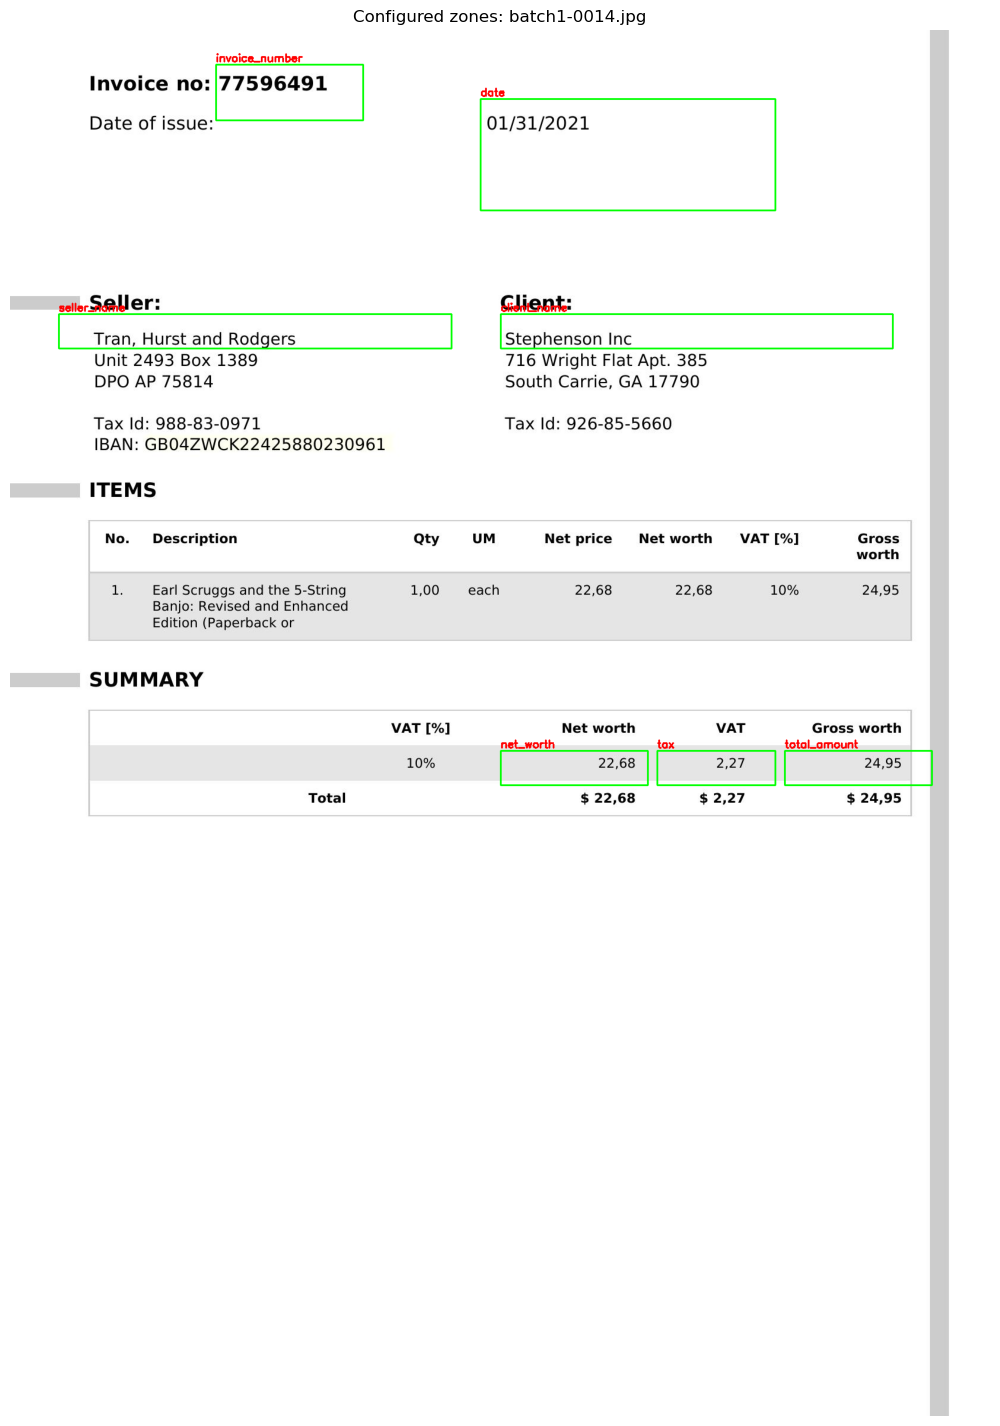

{'invoice_number': '77596491', 'date': '01/31/2021', 'invoice_date': '01/31/2021', 'seller_name': 'Tran, Hurst and Rodgers', 'client_name': 'Stephenson Inc', 'net_worth': '22.68', 'tax': '2.27', 'total_amount': '24.95'}
{'invoice_number': '77596491', 'date': '01/31/2021', 'seller_name': 'Tran, Hurst and Rodgers', 'client_name': 'Stephenson Inc', 'net_worth': '22,68', 'tax': '2,27', 'total_amount': '24.95'}


In [68]:
zones = {
        "default": {
        # Top-left: Invoice number
        "invoice_number": (0.21, 0.025, 0.15, 0.04),

        # Slightly below, shifted right: Date
        "date": (0.48, 0.05, 0.30, 0.08),

        # Middle section
        "seller_name": (0.05, 0.205, 0.40, 0.025),   # Seller block
        "client_name": (0.50, 0.205, 0.40, 0.025),   # Client block

        # Bottom-right summary section
        "net_worth": (0.50, 0.52, 0.15, 0.025),      # Net worth
        "tax": (0.66, 0.52, 0.12, 0.025),           # VAT
        "total_amount": (0.79, 0.52, 0.15, 0.025),  # Gross worth
        }
        }

# 1) Create the pipeline
basic_pipeline = InvoiceZonalOCRPipeline(template_zones=zones,
    output_dir="../finalproject_data/output_images/basic_ocr"
)

# 2) Tune zones visually on one representative invoice
sample_image = "../finalproject_data/batch_1/batch1_1/batch1-0014.jpg"
basic_pipeline.visualize_zones(sample_image, template_name="default")

# 3) Process one invoice
result = basic_pipeline.process_invoice(sample_image, template_name="default")
print(result["fields"])
print(result["zone_text"])


**Batch zonal inference.** Process selected batch subfolders (with sampling), concatenate predictions into `pred_df`.


In [69]:
# 4) Batch process a folder of invoice images
# Define the subfolders you want to process
subfolders = ["batch1_1", "batch1_2", "batch1_3"]
base_path = "../finalproject_data/batch_1/"

# Process each folder and store the resulting dataframes in a list
all_preds = [
    basic_pipeline.process_folder(f"{base_path}{folder}", template_name="default", sample_frac=0.2) 
    for folder in subfolders
]

# Concatenate all dataframes into one
pred_df = pd.concat(all_preds, ignore_index=True)
print(pred_df.head())

Processing 99 images...


Processing invoices: 100%|██████████| 99/99 [01:48<00:00,  1.10s/it]


Processing 100 images...


Processing invoices: 100%|██████████| 100/100 [02:00<00:00,  1.20s/it]


Processing 97 images...


Processing invoices: 100%|██████████| 97/97 [01:50<00:00,  1.14s/it]

         File Name                                         image_path  \
0  batch1-0328.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
1  batch1-0058.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
2  batch1-0013.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
3  batch1-0380.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
4  batch1-0141.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   

   success invoice_number        date invoice_date              seller_name  \
0     True       14165207  02/13/2014   02/13/2014               Patel-Park   
1     True       80489404  12/21/2013   12/21/2013             Gonzalez LLC   
2     True       57986024  10/17/2015   10/17/2015              Schmidt LLC   
3     True       13310164  01/16/2020   01/16/2020           Montgomery LLC   
4     True       73783721  10/22/2011   10/22/2011  Wood, Nichols and Perry   

                  client_name net_worth   tax total_amount  
0  Adkins, Hodges and Haw

**Baseline evaluation.** Score `pred_df` against `ground_truth_df` and collect per-field metrics.


In [70]:
metrics_df = basic_pipeline.evaluate_against_ground_truth(pred_df, ground_truth_df)

         field  accuracy  precision   recall       f1  support
   client_name  0.996390   0.996390 0.996390 0.996390      277
   seller_name  0.996390   0.996390 0.996390 0.996390      277
invoice_number  1.000000   1.000000 1.000000 1.000000      277
  invoice_date  1.000000   1.000000 1.000000 1.000000      277
           tax  0.144404   0.325203 0.144404 0.200000      277
  total_amount  0.093863   0.168831 0.093863 0.120650      277
     net_worth  0.126354   0.246479 0.126354 0.167064      277


**Baseline metric plots.** Visualize evaluation output from the zonal pipeline.


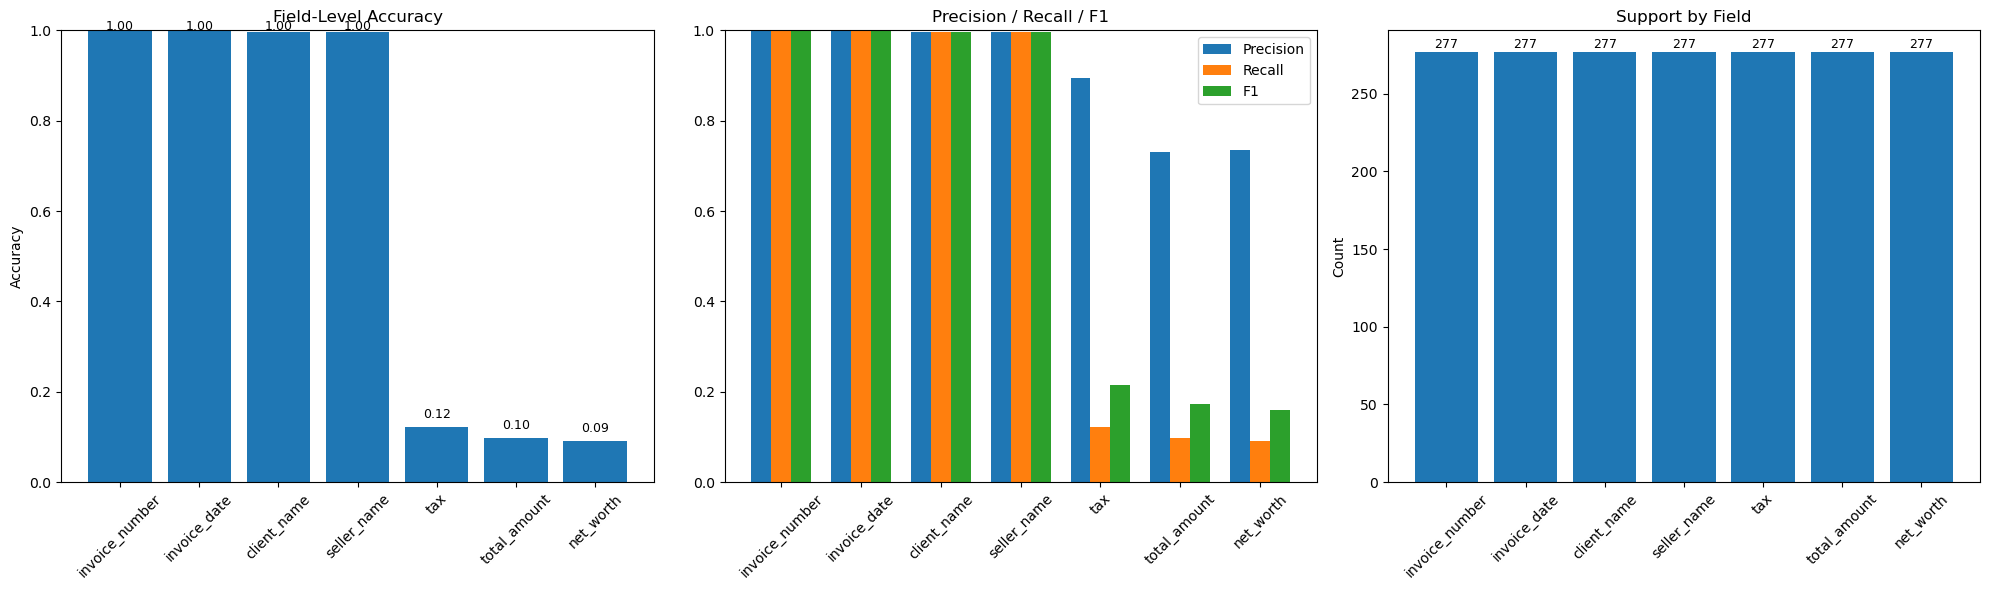

In [47]:
basic_pipeline.visualize_evaluation_metrics(metrics_df)

**Numeric parsing debug.** Sample invoices and compare raw zone OCR, parsed amounts, `pred_df` values, and ground truth for money fields.


In [48]:
# Debug numeric parsing for basic model (20 sampled invoices)
# Shows raw OCR zone text vs parsed value vs GT for: tax, total_amount, net_worth.

from scripts.basic_model import clean_amount

if "pred_df" not in globals() or pred_df is None or len(pred_df) == 0:
    raise ValueError("Run the basic model inference cell first so `pred_df` exists.")
if "ground_truth_df" not in globals() or ground_truth_df is None or len(ground_truth_df) == 0:
    raise ValueError("Run the ground-truth loading cell first so `ground_truth_df` exists.")

fields = ["tax", "total_amount", "net_worth"]
sample_n = min(20, len(pred_df))
sample_df = pred_df.sample(n=sample_n, random_state=42).copy()
gt_cols = ["File Name"] + [f for f in fields if f in ground_truth_df.columns]
sample_df = sample_df.merge(ground_truth_df[gt_cols], on="File Name", how="left", suffixes=("", "_gt"))

rows = []
for _, r in sample_df.iterrows():
    img_path = r.get("image_path")
    if not isinstance(img_path, str) or not img_path:
        continue

    inv = basic_pipeline.process_invoice(img_path, template_name="default")
    zone_text = inv.get("zone_text", {}) or {}

    for field in fields:
        raw_text = zone_text.get(field)
        parsed_from_raw = clean_amount(raw_text)
        rows.append({
            "File Name": r.get("File Name"),
            "field": field,
            "raw_zone_text": raw_text,
            "parsed_from_raw": parsed_from_raw,
            "pred_df_value": r.get(field),
            "gt_value": r.get(field + "_gt"),
        })

numeric_debug_df = pd.DataFrame(rows)

for c in ["parsed_from_raw", "pred_df_value", "gt_value"]:
    numeric_debug_df[c + "_num"] = pd.to_numeric(numeric_debug_df[c], errors="coerce").round(2)

numeric_debug_df["parsed_matches_gt"] = (
    numeric_debug_df["parsed_from_raw_num"] == numeric_debug_df["gt_value_num"]
)
numeric_debug_df["pred_matches_gt"] = (
    numeric_debug_df["pred_df_value_num"] == numeric_debug_df["gt_value_num"]
)

print(f"Sampled invoices: {sample_n}")
print(f"Rows in debug table: {len(numeric_debug_df)}")
display(numeric_debug_df[[
    "File Name", "field", "raw_zone_text", "parsed_from_raw", "pred_df_value", "gt_value",
    "parsed_matches_gt", "pred_matches_gt"
]])

print("\nMatch rates by field")
display(
    numeric_debug_df.groupby("field")[["parsed_matches_gt", "pred_matches_gt"]]
    .mean()
    .rename(columns={"parsed_matches_gt": "parsed_match_rate", "pred_matches_gt": "pred_match_rate"})
)


Sampled invoices: 20
Rows in debug table: 60


,File Name,field,raw_zone_text,parsed_from_raw,pred_df_value,gt_value,parsed_matches_gt,pred_matches_gt
0,batch1-1036.jpg,tax,,NaN,NaN,339.09,False,False
1,batch1-1036.jpg,total_amount,4,NaN,NaN,3729.94,False,False
2,batch1-1036.jpg,net_worth,. .,NaN,NaN,3390.85,False,False
3,batch1-0676.jpg,tax,,NaN,NaN,10.19,False,False
4,batch1-0676.jpg,total_amount,,NaN,NaN,112.12,False,False
5,batch1-0676.jpg,net_worth,,NaN,NaN,101.93,False,False
6,batch1-0052.jpg,tax,,NaN,NaN,22.16,False,False
7,batch1-0052.jpg,total_amount,,NaN,NaN,243.71,False,False
8,batch1-0052.jpg,net_worth,,NaN,NaN,221.55,False,False
9,batch1-0433.jpg,tax,,NaN,NaN,27.89,False,False



Match rates by field


,parsed_match_rate,pred_match_rate
field,,
net_worth,0.05,0.05
tax,0.05,0.05
total_amount,0.05,0.05


## CV Model

**Image preprocessing.** Run `InvoiceImagePreprocessor` on each batch CSV + image folder, combine into `combined_results`, and preview samples.



Processing: batch1_1.csv
Processing 499 images from ../finalproject_data/batch_1/batch1_1.csv
Images location: ../finalproject_data/batch_1/batch1_1


Processing batches: 100%|██████████| 10/10 [00:44<00:00,  4.50s/it]



Processing Complete!
Total images processed: 499
Successful: 499
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_2.csv
Processing 426 images from ../finalproject_data/batch_1/batch1_2.csv
Images location: ../finalproject_data/batch_1/batch1_2


Processing batches: 100%|██████████| 9/9 [00:38<00:00,  4.27s/it]



Processing Complete!
Total images processed: 426
Successful: 426
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_3.csv
Processing 489 images from ../finalproject_data/batch_1/batch1_3.csv
Images location: ../finalproject_data/batch_1/batch1_3


Processing batches: 100%|██████████| 10/10 [00:44<00:00,  4.43s/it]



Processing Complete!
Total images processed: 489
Successful: 489
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

FINAL SUMMARY
Total images across all batches: 1414
Successfully processed: 1414
Failed: 0

Visualizing sample results...


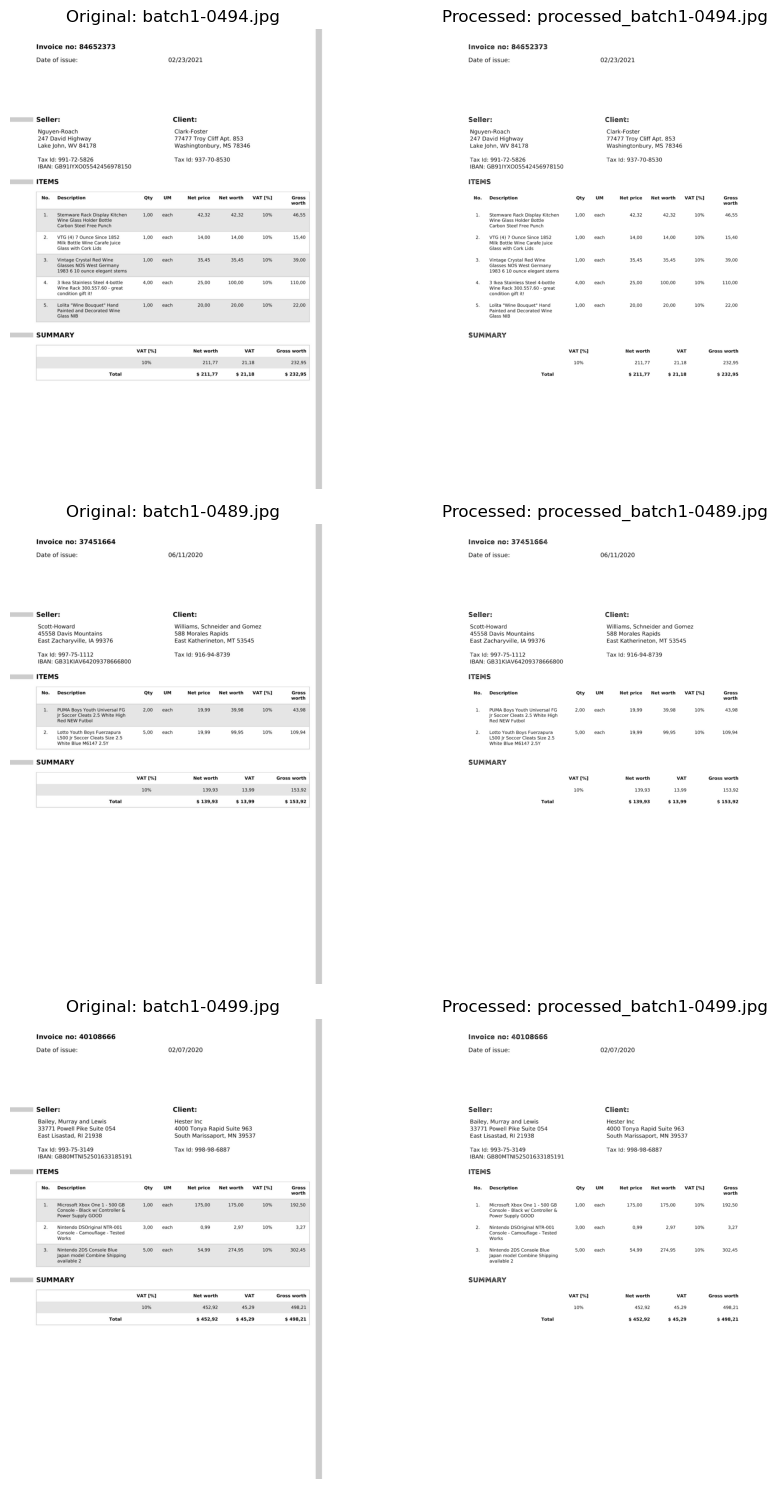

Processed images saved to: ../finalproject_data/processed_images


In [7]:
output_image_path = "../finalproject_data/processed_images"
csv_file_paths = [
    "../finalproject_data/batch_1/batch1_1.csv",
    "../finalproject_data/batch_1/batch1_2.csv",
    "../finalproject_data/batch_1/batch1_3.csv"
]

# Initialize preprocessor
preprocessor = InvoiceImagePreprocessor(output_dir=output_image_path)

image_folders = [
    '../finalproject_data/batch_1/batch1_1',
    '../finalproject_data/batch_1/batch1_2',
    '../finalproject_data/batch_1/batch1_3'
]

# Process all datasets
all_results = []
for csv_file, image_folder in zip(csv_file_paths, image_folders):
    print(f"\n{'='*80}")
    print(f"Processing: {Path(csv_file).name}")
    print(f"{'='*80}")
    
    results_df = preprocessor.process_images(csv_file, image_folder)
    all_results.append(results_df)

# Combine all results
if all_results:
    combined_results = pd.concat(all_results, ignore_index=True)
    
    print(f"\n{'='*80}")
    print("FINAL SUMMARY")
    print(f"{'='*80}")
    print(f"Total images across all batches: {len(combined_results)}")
    print(f"Successfully processed: {len(combined_results[combined_results['status'] == 'success'])}")
    print(f"Failed: {len(combined_results[combined_results['status'] == 'failed'])}")
    
    # Visualize sample results
    print("\nVisualizing sample results...")
    preprocessor.visualize_sample_results(combined_results)
    
    print(f"Processed images saved to: {output_image_path}")

**Merge OCR outputs with labels.** Reload `combined_results.csv` and join to ground truth as `gt_merged_df` for downstream CV/OCR.


In [3]:
# Merge DFs to get processed image file paths
combined_results = pd.read_csv("../finalproject_data/combined_results.csv")
gt_merged_df = pd.merge(ground_truth_df, combined_results, left_on="File Name", right_on="original_file")
gt_merged_df.drop(columns=["File Name", "due_date"], inplace=True)

**Full-page OCR.** Initialize `PytesseractInvoiceTextDetector` and process the full dataset into structured field predictions.


In [10]:
# Initialize text detector
ocr_text_detector = PytesseractInvoiceTextDetector(output_dir="../finalproject_data/output_images", debug_totals=True)

# Process all of the invoices 
summary_df = ocr_text_detector.process_dataset(combined_results, sample_frac=None)

Processing 1414 images...


Processing OCR batches: 100%|██████████| 142/142 [17:55<00:00,  7.57s/it]


TEXT DETECTION SUMMARY
Total images processed: 1414
Successful extractions: 1414
Failed extractions: 0
Average words per image: 142.9
Average confidence: 93.7%

Extracted invoice fields:
  invoice_number: 1414 images (100.0%)
  invoice_date: 1414 images (100.0%)
  seller_name: 1411 images (99.8%)
  client_name: 1413 images (99.9%)
  tax: 1414 images (100.0%)
  net_worth: 1409 images (99.6%)
  total_amount: 1414 images (100.0%)


**Evaluate text detector.** Hold out a test split from `gt_merged_df` and compute field-level metrics vs ground truth.


In [11]:
train_df, test_df = train_test_split(gt_merged_df, test_size=0.2, random_state=42)

# Produce metrics
metrics_df, overall = ocr_text_detector.evaluate_against_ground_truth(test_df)

print(metrics_df)
print("\nOverall:", overall)

Prediction rows: 1414
Prediction unique keys: 1413
Ground truth rows: 283
Ground truth unique keys: 283
Key overlap: 283
Key overlap: 283
            field  ground_truth_count  predicted_count  correct  accuracy  \
0  invoice_number                 283              283      281  0.992933   
1    invoice_date                 283              283      283  1.000000   
2     seller_name                 283              282      280  0.989399   
3     client_name                 283              283      283  1.000000   
4       net_worth                 283              281      274  0.968198   
5    total_amount                 283              283      276  0.975265   
6             tax                 283              283      281  0.992933   

   precision    recall        f1  
0   0.992933  0.992933  0.992933  
1   1.000000  1.000000  1.000000  
2   0.992908  0.989399  0.991150  
3   1.000000  1.000000  1.000000  
4   0.975089  0.968198  0.971631  
5   0.975265  0.975265  0.975265  


**Money-field mismatches.** List tax / net / total rows where normalized prediction ≠ ground truth (evaluation-aligned normalization).


In [ ]:
# Mismatch-only: tax, net_worth, total_amount (_gt vs _pred), same normalization as evaluation

_pred_rows = []
for _r in ocr_text_detector.full_results:
    _row = {"processed_file": _r["filename"]}
    _row.update(_r.get("invoice_fields", {}))
    _pred_rows.append(_row)
_money_pred_df = pd.DataFrame(_pred_rows)

_merge_key = "processed_file"
_money_merged = gt_merged_df.merge(
    _money_pred_df,
    on=_merge_key,
    how="inner",
    suffixes=("_gt", "_pred"),
)

_money_fields = ["tax", "net_worth", "total_amount"]

def _money_norm_series(series):
    return series.apply(normalize_money)

_mismatch_mask = np.zeros(len(_money_merged), dtype=bool)
for _f in _money_fields:
    _gt_n = _money_norm_series(_money_merged[f"{_f}_gt"])
    _pr_n = _money_norm_series(_money_merged[f"{_f}_pred"])
    _valid_gt = _gt_n.notna()
    _valid_pr = _pr_n.notna()
    _correct = (_gt_n == _pr_n) & _valid_gt & _valid_pr
    _mismatch_mask |= ~_correct

_money_mismatch_cols = []
for _f in _money_fields:
    _money_mismatch_cols.extend([f"{_f}_gt", f"{_f}_pred"])

_out_cols = [_merge_key] + _money_mismatch_cols
money_field_mismatches_df = _money_merged.loc[_mismatch_mask, _out_cols].copy()
print(f"Mismatch rows: {len(money_field_mismatches_df)} / inner-join rows: {len(_money_merged)}")
money_field_mismatches_df


Mismatch rows: 47 / inner-join rows: 1416


,processed_file,tax_gt,tax_pred,net_worth_gt,net_worth_pred,total_amount_gt,total_amount_pred
15,processed_batch1-0210.jpg,38.66,38.66,347.94,386.60,386.60,425.26
35,processed_batch1-0167.jpg,8.66,8.66,77.90,86.56,86.56,95.22
41,processed_batch1-0098.jpg,0.20,0.20,1.79,1.99,1.99,2.19
44,processed_batch1-0082.jpg,37.15,37.15,334.36,371.51,371.51,408.66
45,processed_batch1-0114.jpg,0.30,0.30,2.69,2.99,2.99,3.29
56,processed_batch1-0066.jpg,0.20,0.20,1.79,1.99,1.99,2.19
112,processed_batch1-0429.jpg,26.14,26.14,235.27,261.41,261.41,287.55
174,processed_batch1-0449.jpg,1610.11,101.14,16101.14,17711.25,17711.25,17711.25
205,processed_batch1-0176.jpg,5117.76,117.76,51177.59,56295.35,56295.35,56295.35
220,processed_batch1-0064.jpg,491.98,411.82,4919.84,491.98,5411.82,5411.82


**Dashboard & samples.** Open the interactive OCR analysis dashboard and visualize a few text-extraction overlays.



Invoice Processing Analysis Dashboard

PROCESSING OVERVIEW
Total images processed: 1,414
Successful extractions: 1,414 (100.0%)
Failed extractions: 0 (0.0%)

FIELD EXTRACTION SUCCESS RATES
  invoice_number : 100.0%
  invoice_date   : 100.0%
  seller_name    :  99.8%
  client_name    :  99.9%
  tax            : 100.0%
  net_worth      :  99.6%
  total_amount   : 100.0%


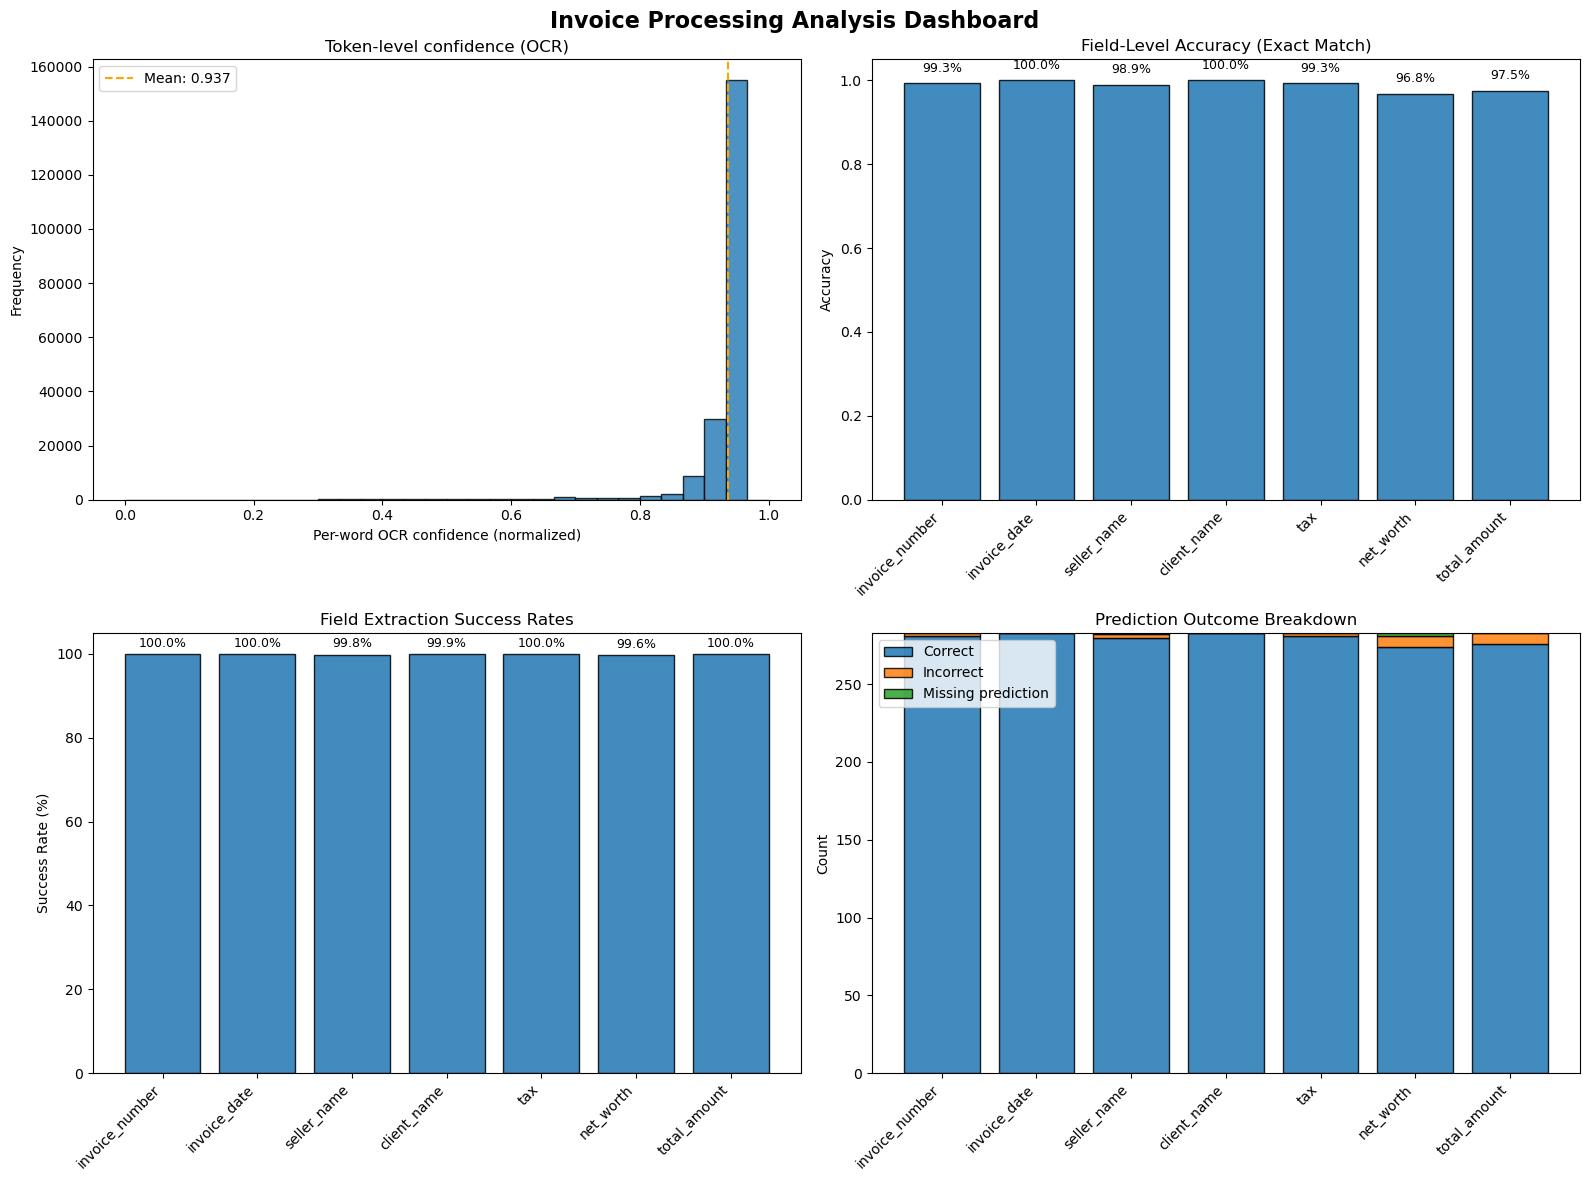


Sample 1: processed_batch1-0494.jpg
Total words detected: 165
Average confidence: 93.958

Extracted Invoice Fields:
  invoice_number: 84652373
  invoice_date: 2021-02-23
  seller_name: Nguyen-Roach
  client_name: Clark-Foster
  tax: 21.18
  net_worth: 211.77
  total_amount: 232.95

Sample extracted text (first 10 words):
  Invoice no: 84652373 Date of issue: 02/23/2021 Seller: Client: Nguyen-Roach...


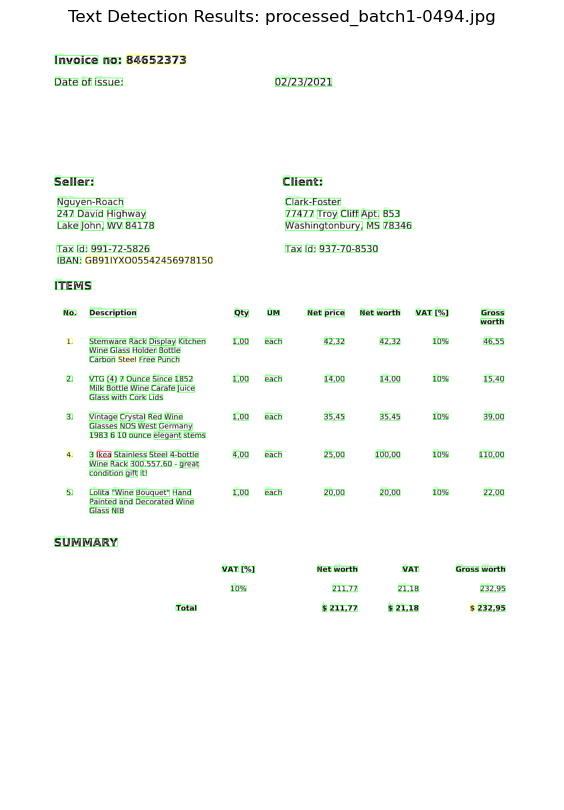


Extracted Invoice Fields:
  invoice_number: 84652373
  invoice_date: 2021-02-23
  seller_name: Nguyen-Roach
  client_name: Clark-Foster
  tax: 21.18
  net_worth: 211.77
  total_amount: 232.95

Sample 2: processed_batch1-0489.jpg
Total words detected: 108
Average confidence: 94.148

Extracted Invoice Fields:
  invoice_number: 37451664
  invoice_date: 2020-06-11
  seller_name: Scott-Howard
  client_name: Williams, Schneider and Gomez
  tax: 13.99
  net_worth: 139.93
  total_amount: 153.92

Sample extracted text (first 10 words):
  Invoice no: 37451664 Date of issue: 06/11/2020 Seller: Client: Scott-Howard...


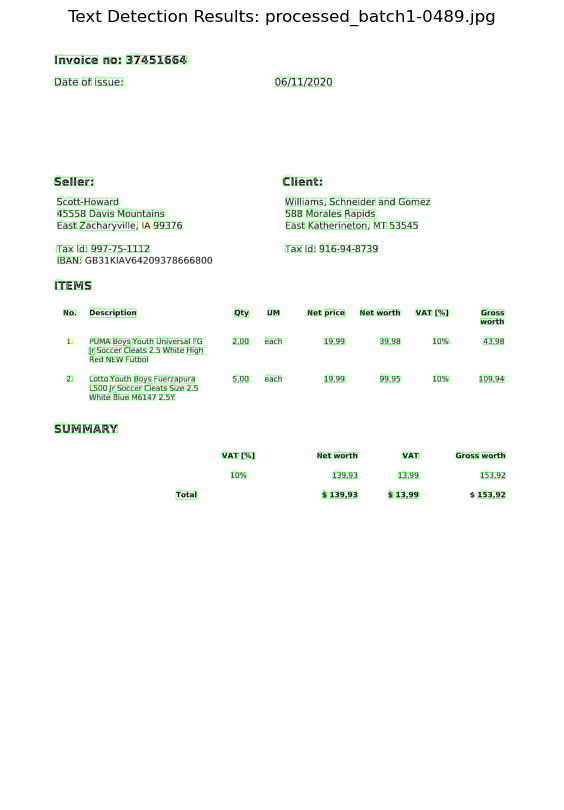


Extracted Invoice Fields:
  invoice_number: 37451664
  invoice_date: 2020-06-11
  seller_name: Scott-Howard
  client_name: Williams, Schneider and Gomez
  tax: 13.99
  net_worth: 139.93
  total_amount: 153.92

Sample 3: processed_batch1-0499.jpg
Total words detected: 129
Average confidence: 93.566

Extracted Invoice Fields:
  invoice_number: 40108666
  invoice_date: 2020-02-07
  seller_name: Bailey, Murray and Lewis
  client_name: Hester Inc
  tax: 45.29
  net_worth: 452.92
  total_amount: 498.21

Sample extracted text (first 10 words):
  Invoice no: 40108666 Date of issue: 02/07/2020 Seller: Client: Bailey,...


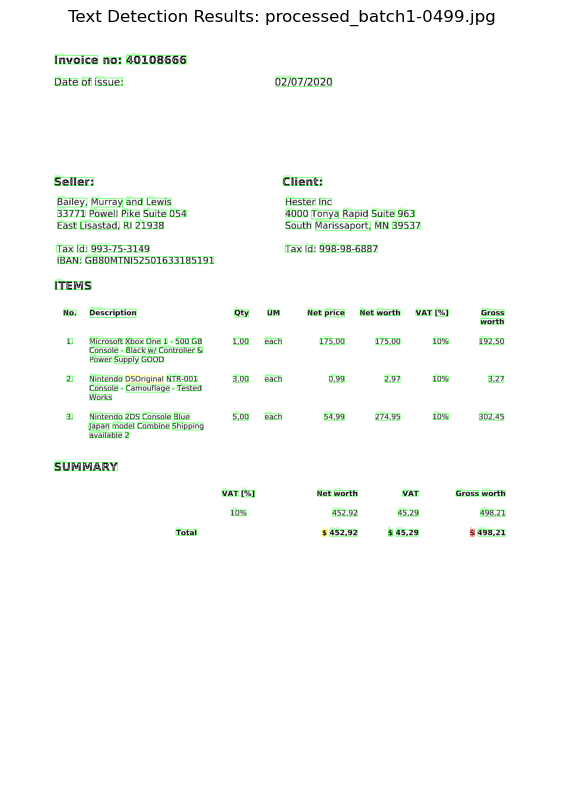


Extracted Invoice Fields:
  invoice_number: 40108666
  invoice_date: 2020-02-07
  seller_name: Bailey, Murray and Lewis
  client_name: Hester Inc
  tax: 45.29
  net_worth: 452.92
  total_amount: 498.21


In [13]:
dashboard_stats = create_analysis_dashboard(
    ocr_text_detector.full_results,
    metrics_df=metrics_df,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    panel_model="ocr",
)

visualize_sample_results(
    ocr_text_detector.full_results,
    visualize_text_fn=ocr_text_detector.visualize_text_extraction,
    n_samples=3
)